# UK E-Commerce Revenue Analysis

This analysis focuses on transaction cleaning, customer and country-level revenue, product performance, monthly sales trends and cancellation behaviour.

In [1]:
# importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

The original transaction data is loaded and checked before making any changes.

In [25]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

print(df.head())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
(541909, 8)


## Checking the dataset structure

Column types and missing values are reviewed before the cleaning stage.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
# missing values

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## Separating cancellations and returns

Cancelled invoices and negative quantities are kept separately before creating the cleaned sales dataset.

In [6]:
# separating cancelled orders

cancelled_orders = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
].copy()

# keeping negative quantities for return analysis
returns = df[df["Quantity"] < 0].copy()

print("Cancelled rows:", len(cancelled_orders))
print("Negative quantity rows:", len(returns))

Cancelled rows: 9288
Negative quantity rows: 10624


## Preparing the sales dataset

Rows without a CustomerID are excluded from customer-level analysis, while cancelled orders and negative quantities are removed from the main sales dataset.

In [7]:
# preparing clean sales data

sales = df.dropna(subset=["CustomerID"]).copy()

sales = sales[
    ~sales["InvoiceNo"].astype(str).str.startswith("C")
]

sales = sales[sales["Quantity"] > 0]

sales["CustomerID"] = sales["CustomerID"].astype(int)

print("Clean sales rows:", len(sales))
print("Unique customers:", sales["CustomerID"].nunique())

Clean sales rows: 397924
Unique customers: 4339


## Creating the revenue metric

Revenue is calculated for each valid sales transaction using quantity and unit price.

In [8]:
# calculating revenue

sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]

print(sales[["Quantity", "UnitPrice", "Revenue"]].head())

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


## Aggregating customer performance

Customer-level metrics are calculated to compare revenue, order frequency and average order value.

In [9]:
customer_summary = (sales.groupby("CustomerID").agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique")
    )
)

customer_summary["Avg_Order_Value"] = (customer_summary["Total_Revenue"]/ customer_summary["Total_Orders"])

customer_summary = customer_summary.sort_values("Total_Revenue", ascending=False)

print(customer_summary.head())

            Total_Revenue  Total_Orders  Avg_Order_Value
CustomerID                                              
14646           280206.02            74      3786.567838
18102           259657.30            60      4327.621667
17450           194550.79            46      4229.365000
16446           168472.50             2     84236.250000
14911           143825.06           201       715.547562


## Comparing country-level revenue

Revenue and order activity are aggregated by country to measure each market's contribution to total sales.

In [10]:
# aggregating country metrics

country_summary = (
    sales.groupby("Country")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Order_Count=("InvoiceNo", "nunique")
    )
)

country_summary["Revenue_Share"] = (
    country_summary["Total_Revenue"]
    / country_summary["Total_Revenue"].sum()
    * 100
)

country_summary = country_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

print(country_summary.head(10).round(2))

                Total_Revenue  Order_Count  Revenue_Share
Country                                                  
United Kingdom     7308391.55        16649          82.01
Netherlands         285446.34           95           3.20
EIRE                265545.90          260           2.98
Germany             228867.14          457           2.57
France              209024.05          389           2.35
Australia           138521.31           57           1.55
Spain                61577.11           90           0.69
Switzerland          56443.95           51           0.63
Belgium              41196.34           98           0.46
Sweden               38378.33           36           0.43


## Analyzing monthly revenue

Monthly revenue is aggregated to identify the strongest sales periods and the peak month.

In [11]:
# monthly revenue

sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"])

sales["Month"] = sales["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue = (
    sales.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

print(monthly_revenue)

      Month      Revenue
0   2010-12   572713.890
1   2011-01   569445.040
2   2011-02   447137.350
3   2011-03   595500.760
4   2011-04   469200.361
5   2011-05   678594.560
6   2011-06   661213.690
7   2011-07   600091.011
8   2011-08   645343.900
9   2011-09   952838.382
10  2011-10  1039318.790
11  2011-11  1161817.380
12  2011-12   518192.790


In [13]:
# the peak month

peak_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmax()]

print(peak_month)

Month         2011-11
Revenue    1161817.38
Name: 11, dtype: object


## Identifying the top-selling products

Product quantities are aggregated to find the items with the highest total sales volume.

In [14]:
# finding the top products

top_products = (sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
PACK OF 12 LONDON TISSUES             25345
PACK OF 60 PINK PAISLEY CAKE CASES    24264
BROCADE RING PURSE                    22963
VICTORIAN GLASS HANGING T-LIGHT       22433
ASSORTED COLOURS SILK FAN             21876
RED  HARMONICA IN BOX                 20975
JUMBO BAG PINK POLKADOT               20165
SMALL POPCORN HOLDER                  18252
LUNCH BAG RED RETROSPOT               17697
60 TEATIME FAIRY CAKE CASES           17689
Name: Quantity, dtype: int64


## Calculating cancellation rate by country

Cancellation rate is calculated from unique invoices to compare return behaviour across markets without overcounting multi-item orders.

In [16]:
# preparing invoice-level cancellation data

invoice_status = (df[["InvoiceNo", "Country"]].drop_duplicates().copy())

invoice_status["Cancelled"] = (
    invoice_status["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

country_returns = (
    invoice_status.groupby("Country")
    .agg(
        Total_Orders=("InvoiceNo", "nunique"),
        Cancelled_Orders=("Cancelled", "sum")
    )
)

country_returns["Cancellation_Rate"] = (
    country_returns["Cancelled_Orders"]
    / country_returns["Total_Orders"]
    * 100
)

country_returns = country_returns.sort_values("Cancellation_Rate", ascending=False)

print(country_returns.round(2))

                      Total_Orders  Cancelled_Orders  Cancellation_Rate
Country                                                                
Czech Republic                   5                 3              60.00
Malta                           10                 5              50.00
Saudi Arabia                     2                 1              50.00
Japan                           28                 9              32.14
Italy                           55                17              30.91
Singapore                       10                 3              30.00
USA                              7                 2              28.57
Switzerland                     74                20              27.03
Hong Kong                       15                 4              26.67
Bahrain                          4                 1              25.00
Germany                        603               146              24.21
Sweden                          46                10            

In [18]:
# flagging markets above the overall cancellation rate

overall_cancellation_rate = (invoice_status["Cancelled"].mean() * 100)

country_returns["High_Return_Market"] = (
    country_returns["Cancellation_Rate"] > overall_cancellation_rate
)

print("Overall cancellation rate:", round(overall_cancellation_rate, 2), "%")
print(country_returns.round(2))

Overall cancellation rate: 14.81 %
                      Total_Orders  Cancelled_Orders  Cancellation_Rate  \
Country                                                                   
Czech Republic                   5                 3              60.00   
Malta                           10                 5              50.00   
Saudi Arabia                     2                 1              50.00   
Japan                           28                 9              32.14   
Italy                           55                17              30.91   
Singapore                       10                 3              30.00   
USA                              7                 2              28.57   
Switzerland                     74                20              27.03   
Hong Kong                       15                 4              26.67   
Bahrain                          4                 1              25.00   
Germany                        603               146             

## Visualizing monthly revenue

The monthly trend shows how revenue changed throughout the available period.

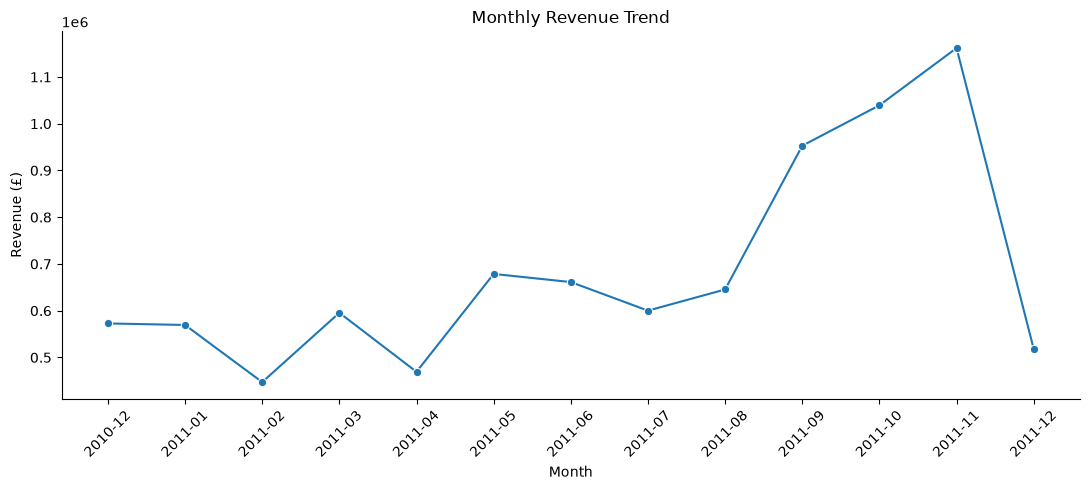

In [19]:
# plotting monthly revenue trend

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

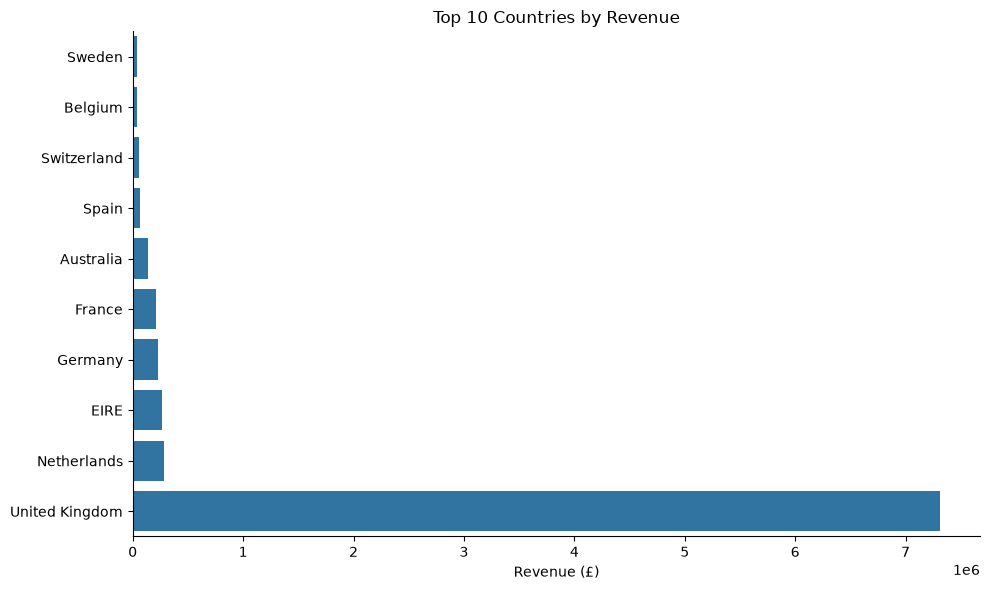

In [20]:
# plotting the top 10 countries by revenue

top_countries = (
    country_summary
    .head(10)
    .sort_values("Total_Revenue")
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_countries["Total_Revenue"],
    y=top_countries.index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

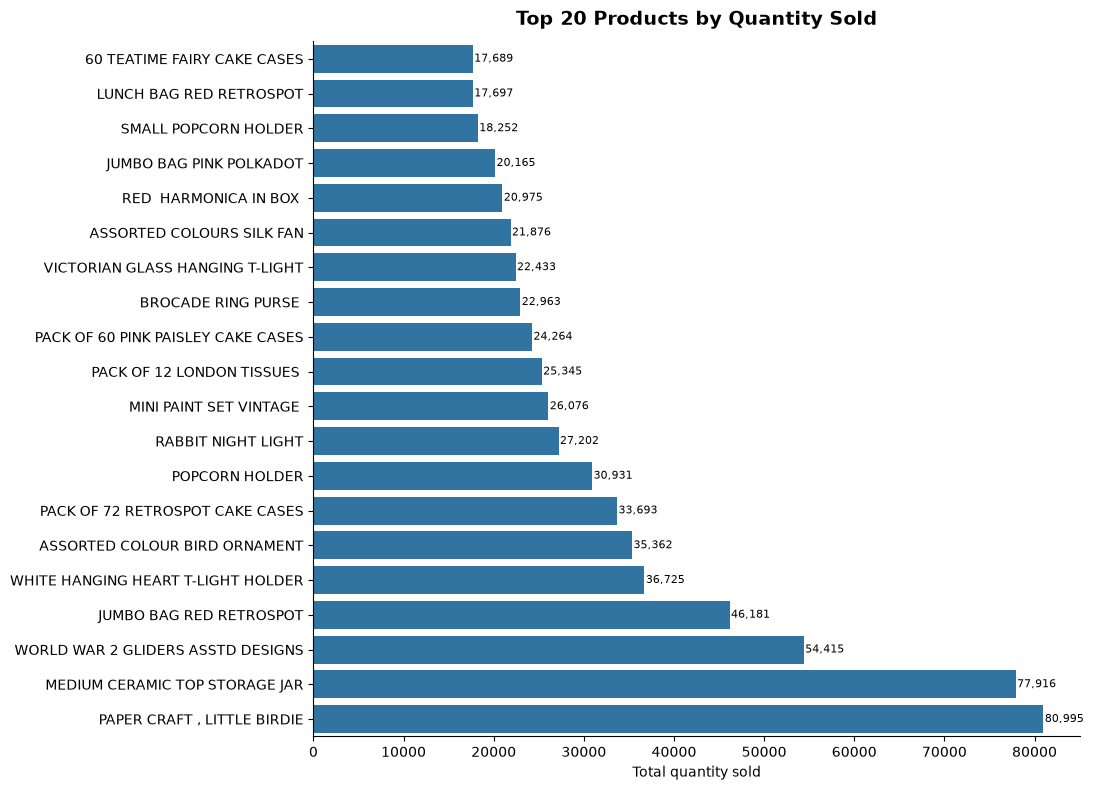

In [21]:
# plotting the top 20 products by quantity sold

product_plot = top_products.sort_values()

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    x=product_plot.values,
    y=product_plot.index
)

for i, value in enumerate(product_plot.values):
    ax.text(
        value + 150,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=8
    )

plt.title(
    "Top 20 Products by Quantity Sold",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.xlabel("Total quantity sold")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

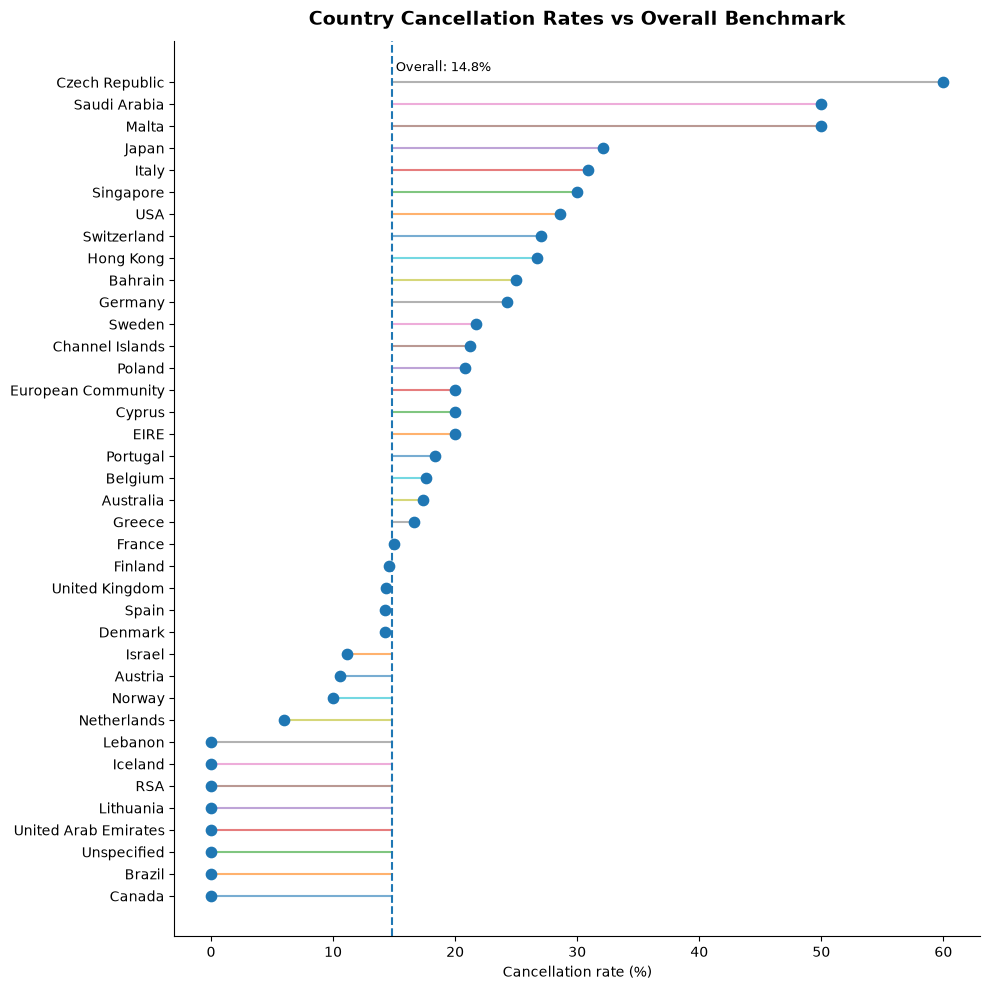

In [23]:
# comparing country cancellation rates with the overall benchmark

return_plot = (
    country_returns
    .sort_values("Cancellation_Rate")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 10))

for i, row in return_plot.iterrows():
    ax.plot(
        [overall_cancellation_rate, row["Cancellation_Rate"]],
        [i, i],
        linewidth=1.5,
        alpha=0.6
    )

ax.scatter(
    return_plot["Cancellation_Rate"],
    range(len(return_plot)),
    s=55,
    zorder=3
)

ax.axvline(
    overall_cancellation_rate,
    linestyle="--",
    linewidth=1.5
)

ax.set_yticks(range(len(return_plot)))
ax.set_yticklabels(return_plot["Country"])

ax.set_title(
    "Country Cancellation Rates vs Overall Benchmark",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Cancellation rate (%)")
ax.set_ylabel("")

ax.text(
    overall_cancellation_rate,
    len(return_plot) - 0.5,
    f" Overall: {overall_cancellation_rate:.1f}%",
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

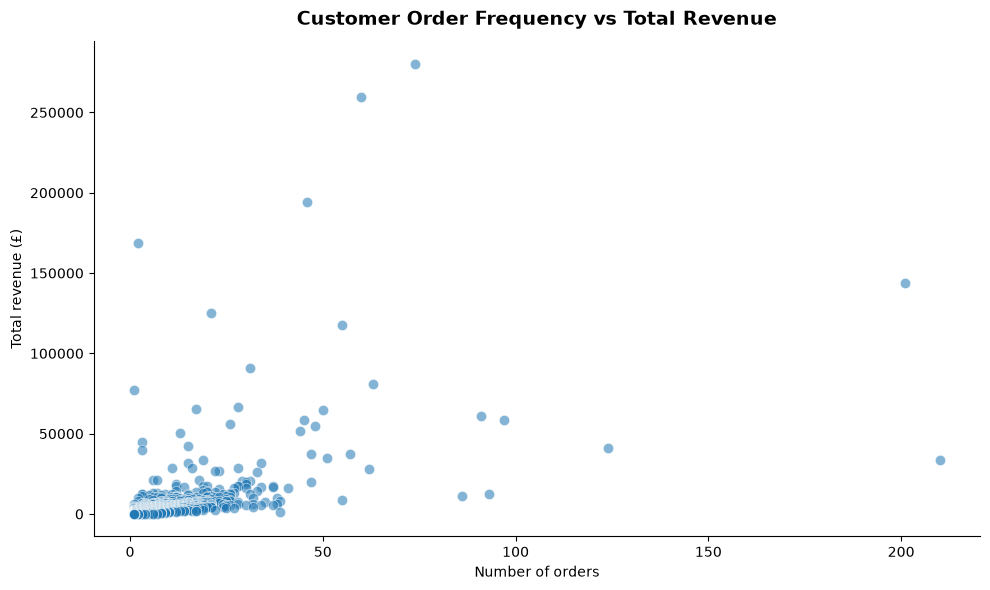

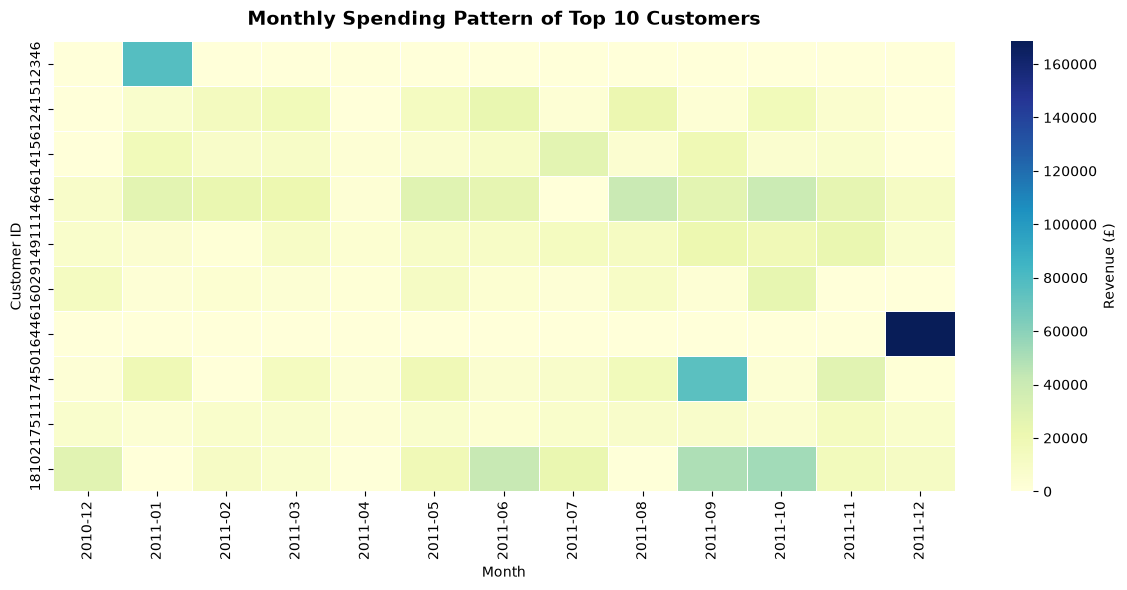

In [26]:
# visualizing monthly spending of the top 10 customers

top_customers = (
    customer_summary
    .head(10)
    .index
)

top_customer_monthly = (
    sales[sales["CustomerID"].isin(top_customers)]
    .groupby(["CustomerID", "Month"])["Revenue"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    top_customer_monthly,
    cmap="YlGnBu",
    linewidths=0.4,
    cbar_kws={"label": "Revenue (£)"}
)

plt.title(
    "Monthly Spending Pattern of Top 10 Customers",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

Country
RSA                     58.00
Israel                  49.00
Lebanon                 45.00
Cyprus                  37.44
Switzerland             36.10
USA                     35.80
Brazil                  32.00
Singapore               31.14
Unspecified             29.88
Norway                  29.69
Greece                  29.00
Channel Islands         28.73
EIRE                    27.79
Spain                   27.38
Iceland                 26.00
Portugal                25.23
Canada                  25.17
Netherlands             24.87
Austria                 23.41
United Arab Emirates    22.67
Malta                   22.40
France                  21.35
Denmark                 21.06
Australia               20.75
Belgium                 20.72
United Kingdom          20.69
Italy                   19.95
Germany                 19.73
Poland                  17.37
Japan                   16.89
Finland                 16.61
European Community      15.00
Czech Republic          12.50
Sw

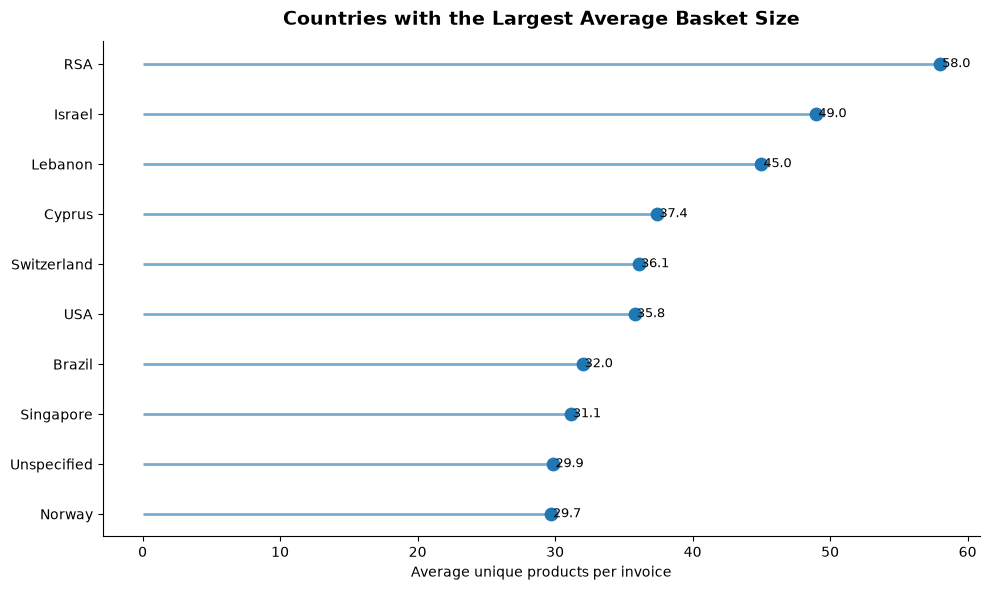

In [28]:
# calculating and visualizing average basket size by country

invoice_baskets = (
    sales.groupby(["Country", "InvoiceNo"])["StockCode"]
    .nunique()
    .reset_index(name="Unique_Products")
)

basket_size = (
    invoice_baskets.groupby("Country")["Unique_Products"]
    .mean()
    .sort_values(ascending=False)
)

print(basket_size.round(2))

# keeping the top 10 countries for a cleaner comparison
basket_plot = basket_size.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.hlines(
    y=basket_plot.index,
    xmin=0,
    xmax=basket_plot.values,
    linewidth=2,
    alpha=0.6
)

plt.scatter(
    basket_plot.values,
    basket_plot.index,
    s=80
)

for i, value in enumerate(basket_plot.values):
    plt.text(
        value + 0.15,
        i,
        f"{value:.1f}",
        va="center",
        fontsize=9
    )

plt.title(
    "Countries with the Largest Average Basket Size",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.xlabel("Average unique products per invoice")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()